# DeSFAM SyscallAD — Huấn luyện và Đánh giá Mô hình trên DongTing

Notebook này trình bày quy trình tái hiện đầu-cuối của bộ phát hiện bất thường **SyscallAD** (DeSFAM, Dong và cộng sự) trên tập dữ liệu DongTing. Quy trình gồm các giai đoạn: nạp dữ liệu, trượt cửa sổ, trích xuất đặc trưng, huấn luyện mô hình chỉ trên dữ liệu lành tính (Isolation Forest và VAE), hợp nhất điểm số, và xác định ngưỡng quyết định; kết quả được lưu thành các artifact phục vụ bộ phát hiện trực tuyến.

| Giai đoạn | Nội dung |
|---|---|
| 1 · Nạp dữ liệu | Đọc 18,966 chuỗi syscall từ bản phát hành DongTing đầy đủ |
| 2 · Trượt cửa sổ | Cửa sổ độ dài L=15, bước trượt S=3 — đơn vị quyết định của bộ phát hiện |
| 3 · Trích xuất đặc trưng | Vector 43 chiều trên alphabet khớp cảm biến Tetragon (§IV.B.3) |
| 4 · Chuẩn hoá đặc trưng | RobustScaler(p1..p99) ước lượng trên cửa sổ lành tính |
| 5 · Huấn luyện mô hình | Isolation Forest và VAE (3 hạt giống), chỉ trên dữ liệu lành tính |
| 6 · Ngưỡng quyết định | Ngưỡng khởi tạo T₀ = phân vị 99.5 của sai số lành tính (§IV.B.3) |
| 7 · Kết quả thực nghiệm | AUC validation/test, đường cong ROC, phân tích độ nhạy theo α |
| 8 · Lưu artifact | Các tệp trong `model/` mà bộ phát hiện nạp khi khởi động |
| 9 · Ánh xạ tới bộ phát hiện trực tuyến | Tương ứng giữa mục notebook và bảng điều khiển Grafana |
| 10 · Giới hạn | Alphabet cảm biến, đặc trưng thời gian, tăng cường dữ liệu |

> Toàn bộ phép tính được nhập từ `train.py` (nguồn chân lý duy nhất); notebook chỉ bổ sung diễn giải và trực quan hoá. Thực thi notebook tương đương lệnh `docker compose -f docker-compose.pipeline.yml up --build`.


## 1. Nạp dữ liệu

Tập dữ liệu gồm 18,966 chuỗi syscall trích từ bản phát hành DongTing đầy đủ: tệp `Baseline.xlsx` đóng vai trò chỉ mục (nhãn, phân tách tập, phiên bản nhân), các tệp `.log` chứa chuỗi syscall. Dữ liệu được phân tách thành ba tập huấn luyện/validation/test theo cột phân loại trong chỉ mục. Hàm nạp trả về bộ năm `(seqs, labels, splits, ver_list, ts_list)`; trên DongTing, `ts_list = None` do dữ liệu được thu thập bằng `strace -v -f`, không kèm dấu thời gian.


In [1]:
# ── Cấu hình ──────────────────────────────────────────────────────────────────
import os, json, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from pathlib import Path
import numpy as np
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

import train  # module handle — needed to set the sensor-alphabet filter (train._ALLOWED_IDS)
from train import (
    CFG, GLOBAL_SEED, set_seeds,
    load_syscall_table, load_sequences,
    fit_vocab_plus, fit_benign_patterns, build_patterns_by_first,
    build_features_windowed, build_features,
    SYSCALL_CATEGORIES, build_id_to_category,
    build_vae, recon_error,
    EnsembleScorer, select_threshold, compute_metrics,
    WINDOW_LEN, WINDOW_STRIDE, USE_SLIDING_WINDOW, USE_TEMPORAL,
    MAX_WINDOWS_PER_SPLIT, PREFIXSPAN_DIMS, TEMPORAL_DIMS,
    SENSOR_ALPHABET_NAMES, USE_SENSOR_ALPHABET,
)

SYSCALL_TBL = os.environ.get('SYSCALL_TBL', '/data/dongting/syscall_64.tbl')
OUTPUT_DIR  = os.environ.get('OUTPUT_DIR',  '/model')
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
set_seeds(GLOBAL_SEED)

# Sensor-alphabet feature vector (khớp docker-compose.pipeline.yml service `train`):
# freq trên syscall phổ biến + disc = presence-bit cho syscall đặc quyền hiếm
# (ptrace/unshare/setns/…, dilution-robust) + stats + cat + prefixspan.
TOP_K_FREQ, TOP_K_DISC, TOP_K_BIGRAMS = 8, 24, 0
ENABLE_STATS = True

print(f'TensorFlow {tf.__version__}  NumPy {np.__version__}')
print(f'Window: length={WINDOW_LEN} stride={WINDOW_STRIDE}  cap_per_split={MAX_WINDOWS_PER_SPLIT:,}')
print(f'Vocab : freq={TOP_K_FREQ}  disc={TOP_K_DISC}  bigrams={TOP_K_BIGRAMS}  stats={ENABLE_STATS}')
print(f'Sensor alphabet: {"ON" if USE_SENSOR_ALPHABET else "OFF"}  ({len(SENSOR_ALPHABET_NAMES)} syscalls)')
print(f'Output: {OUTPUT_DIR}')


TensorFlow 2.21.0  NumPy 2.4.6
Window: length=15 stride=3  cap_per_split=2,000,000
Vocab : freq=8  disc=24  bigrams=0  stats=True
Sensor alphabet: ON  (24 syscalls)
Output: /tmp/nbout


In [2]:
# ── Bảng syscall 64-bit + sensor alphabet ─────────────────────────────────────
name_to_id = load_syscall_table(SYSCALL_TBL)   # bỏ qua x32 ABI → execve=59, ptrace=101 (khớp extractor live)
id_to_name = {v: k for k, v in name_to_id.items()}
print(f'Loaded {len(name_to_id)} syscalls from {SYSCALL_TBL}')

# Giới hạn alphabet về đúng các syscall mà TracingPolicy live phát ra → train và
# serve dùng chung không gian đặc trưng. load_sequences() đọc train._ALLOWED_IDS
# khi parse từng trace (bỏ mọi syscall ngoài alphabet trước khi trượt cửa sổ).
train._ALLOWED_IDS = ({name_to_id[n] for n in SENSOR_ALPHABET_NAMES if n in name_to_id}
                      if USE_SENSOR_ALPHABET else None)
if train._ALLOWED_IDS:
    print(f'Sensor alphabet: {len(train._ALLOWED_IDS)} ids -> {sorted(train._ALLOWED_IDS)}')


Loaded 362 syscalls from /data/dongting/syscall_64.tbl
Sensor alphabet: 24 ids -> [9, 10, 41, 42, 49, 56, 59, 101, 105, 106, 126, 155, 157, 165, 175, 257, 263, 272, 275, 308, 313, 316, 319, 321]


In [3]:
# ── Nạp toàn bộ 18,966 sequence ───────────────────────────────────────────────
seqs, labels, splits, ver_list, ts_list = load_sequences(name_to_id)
print(f'Loaded {len(seqs):,} sequences total  (ts_list is None: {ts_list is None})')

# Tách thành ba tập theo Baseline.xlsx
idx_train = [i for i, s in enumerate(splits) if s == 'train']
idx_val   = [i for i, s in enumerate(splits) if s == 'val']
idx_test  = [i for i, s in enumerate(splits) if s == 'test']

def _pick_ts(idx): return [ts_list[i] for i in idx] if ts_list is not None else None
seqs_train = [seqs[i] for i in idx_train];  ts_train = _pick_ts(idx_train)
seqs_val   = [seqs[i] for i in idx_val];    ts_val   = _pick_ts(idx_val)
seqs_test  = [seqs[i] for i in idx_test];   ts_test  = _pick_ts(idx_test)
y_train = np.array([labels[i] for i in idx_train], dtype=np.int32)
y_val   = np.array([labels[i] for i in idx_val],   dtype=np.int32)
y_test  = np.array([labels[i] for i in idx_test],  dtype=np.int32)

for name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'  {name:5s}: n={len(y):,}  benign={(y==0).sum():,}  attack={(y==1).sum():,}')

[00:00  ram= 0.6G]    Indexing .log members across the dataset zips...


[00:00  ram= 0.6G]    Indexed 18,966 .log files


[00:00  ram= 0.6G]    Reading master index /data/dongting/Baseline.xlsx ...


  Loaded 18874 sequences (92 skipped) from full dataset
Loaded 18,874 sequences total  (ts_list is None: True)
  train: n=14,765  benign=5,416  attack=9,349
  val  : n=1,804  benign=677  attack=1,127
  test : n=2,305  benign=672  attack=1,633


## 2. Tiền xử lý — Trượt cửa sổ

Mỗi chuỗi được phân đoạn thành các cửa sổ trượt độ dài 15, bước trượt 3. Đây là đơn vị quyết định của hệ thống: bộ phát hiện trực tuyến cũng đánh giá trên các cửa sổ độ dài 15 của luồng syscall thời gian thực. Do một số chuỗi tấn công trong DongTing dài tới hàng triệu syscall, tổng số cửa sổ có thể vượt 100 triệu nếu không giới hạn; vì vậy mỗi tập được lấy mẫu ngẫu nhiên với trần `MAX_WINDOWS_PER_SPLIT = 2,000,000`.


Benign  median=21  p95=135  max=49,975
Attack  median=19  p95=16671  max=49,987


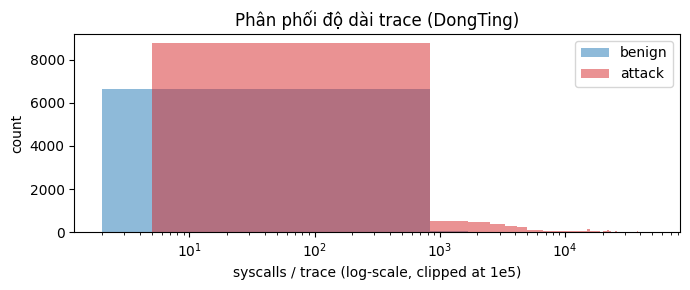

In [4]:
# ── Phân phối độ dài trace (benign vs attack) ─────────────────────────────────
all_lens_n = np.array([len(s) for i, s in enumerate(seqs) if labels[i] == 0])
all_lens_a = np.array([len(s) for i, s in enumerate(seqs) if labels[i] == 1])

print(f'Benign  median={np.median(all_lens_n):.0f}  p95={np.percentile(all_lens_n, 95):.0f}  max={all_lens_n.max():,}')
print(f'Attack  median={np.median(all_lens_a):.0f}  p95={np.percentile(all_lens_a, 95):.0f}  max={all_lens_a.max():,}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(np.clip(all_lens_n, 1, 1e5), bins=60, alpha=0.5, label='benign', color='#1f77b4')
ax.hist(np.clip(all_lens_a, 1, 1e5), bins=60, alpha=0.5, label='attack', color='#d62728')
ax.set_xscale('log'); ax.set_xlabel('syscalls / trace (log-scale, clipped at 1e5)'); ax.set_ylabel('count')
ax.set_title('Phân phối độ dài trace (DongTing)'); ax.legend()
plt.tight_layout(); plt.show()

## 3. Trích xuất đặc trưng — Vector 43 chiều trên alphabet cảm biến

**Căn chỉnh không gian đặc trưng theo cảm biến.** Bộ phát hiện trực tuyến nhận sự kiện qua TracingPolicy `syscall-ad-tracing` của Tetragon, vốn chỉ phát ra 23 syscall liên quan đến an ninh (`execve, clone, setuid/setgid/capset, openat, unlinkat, renameat2, mount, unshare, setns, pivot_root, socket, connect, bind, mprotect, mmap, prctl, memfd_create, splice, ptrace, init/finit_module, bpf`); các syscall tần suất cao như `read/write/close/futex` không được thu thập. Nếu huấn luyện trên toàn bộ không gian syscall của DongTing, các cửa sổ thời gian thực sẽ suy biến và không còn phân biệt được lành tính với tấn công (chi tiết trong `docs/auto-iter-log.md`, iter-2). Do đó `train.py` (`SENSOR_ALPHABET=1`) giới hạn DongTing về đúng 23 syscall này trước khi trượt cửa sổ. Ngoài ra, `load_syscall_table` bỏ qua các dòng ABI x32 nhằm bảo đảm `execve`/`ptrace` mang đúng định danh chuẩn (59/101) như bộ trích xuất trực tuyến sử dụng.

Mỗi cửa sổ được biểu diễn bằng vector 43 chiều gồm năm nhóm đặc trưng:

| Nhóm | Số chiều | Ý nghĩa | Nguồn ước lượng |
|---|---:|---|---|
| `freq_8` | 8 | Tần suất chuẩn hoá của các syscall phổ biến trong alphabet | cửa sổ lành tính |
| `disc_15` | 15 | Chỉ báo hiện diện (nhị phân) của các syscall đặc quyền hiếm (`ptrace`, `unshare`, `setns`, `mount`, `bpf`, …) | cửa sổ lành tính |
| `stats_8` | 8 | Entropy, số syscall phân biệt, log độ dài, tần suất cực đại, phân vị 75, độ lệch chuẩn, độ phủ, độ dài chuẩn hoá | suy ra trực tiếp |
| `cat_10` | 10 | Biểu đồ chuẩn hoá theo 10 nhóm chức năng (tệp/mạng/bộ nhớ/tiến trình/an ninh/…) | bảng tĩnh |
| `prefixspan_2` | 2 | `[cờ khớp, độ dài khớp dài nhất/L]` so với cơ sở dữ liệu mẫu lành tính | PrefixSpan trên cửa sổ lành tính |
| **Tổng** | **43** | | |

Nhóm `disc` (hiện diện nhị phân) được bổ sung vì các syscall đặc quyền hầu như không xuất hiện trong tải lành tính; một bit hiện diện vẫn được kích hoạt ngay cả khi cửa sổ bị pha loãng bởi `openat` lành tính — trường hợp mà đặc trưng tần suất thuần không nắm bắt được (các kịch bản docker-escape và dirty-pipe chỉ chứa khoảng 50% syscall độc hại). Đây là bước trích xuất đặc trưng mà bài báo không quy định chi tiết (§IV.B.3 không xác định số chiều vector); các thành phần nền tảng của bài báo — cửa sổ 15/3, `cat_K`, PrefixSpan trên dữ liệu lành tính, IF+VAE huấn luyện chỉ trên dữ liệu lành tính, RobustScaler(p1..p99) — được giữ nguyên.

Nhóm đặc trưng thời gian (Δt) đã được cài đặt nhưng không kích hoạt trên DongTing: do dữ liệu không có dấu thời gian nên `temporal_3` luôn bằng 0 chiều, và nhóm này chỉ tự kích hoạt khi đầu vào có dấu thời gian. Nhóm `bigrams` được tắt vì gây nhiễu trên alphabet 24 ký hiệu.


In [5]:
# ── Phương pháp 1: Categorical Frequencies (cat_10) ───────────────────────────
cat_cols  = list(SYSCALL_CATEGORIES)
id_to_cat = build_id_to_category(name_to_id)
n_cat     = len(cat_cols)
print(f'10 nhóm chức năng: {cat_cols}')
from collections import Counter
cat_dist = Counter(id_to_cat.values())
for c in cat_cols:
    print(f'  {c:10s} {cat_dist.get(c, 0):3d} syscall')

10 nhóm chức năng: ['process', 'file', 'memory', 'network', 'signal', 'time', 'ipc', 'security', 'io_event', 'other']
  process     38 syscall
  file        94 syscall
  memory      30 syscall
  network     18 syscall
  signal      15 syscall
  time        22 syscall
  ipc         18 syscall
  security    29 syscall
  io_event    19 syscall
  other       79 syscall


In [6]:
# ── Phương pháp 2: PrefixSpan benign-pattern mining (prefixspan_2) ────────────
normal_train_seqs = [seqs_train[i] for i in range(len(seqs_train)) if y_train[i] == 0]
print(f'Mining trên {len(normal_train_seqs):,} trace benign training...')
benign_patterns = fit_benign_patterns(
    normal_train_seqs, WINDOW_LEN, WINDOW_STRIDE,
    CFG['ps_min_support'], CFG['ps_min_len'], CFG['ps_max_len'], CFG['ps_top_n'],
    rng_seed=GLOBAL_SEED)
patterns_by_first = build_patterns_by_first(benign_patterns)
ps_dims = PREFIXSPAN_DIMS if benign_patterns else 0
print(f'PrefixSpan: kept {len(benign_patterns)} pattern  (min_support={CFG["ps_min_support"]}, len={CFG["ps_min_len"]}-{CFG["ps_max_len"]})')
print(f'  ví dụ pattern: {benign_patterns[:3]}')

Mining trên 5,416 trace benign training...


[00:29  ram= 0.9G]    PrefixSpan: mined 11,796 benign windows → 655 frequent (minsup=589) → kept 150 patterns


PrefixSpan: kept 150 pattern  (min_support=0.05, len=3-6)
  ví dụ pattern: [(9, 9, 9), (9, 9, 9, 9), (9, 9, 9, 9, 9)]


In [7]:
# ── Phương pháp 3: Engineered vocab — freq (phổ biến) + disc (presence syscall hiếm) ───
print(f'Fitting top-K vocab trên {len(normal_train_seqs):,} trace benign training...')
top_ids, disc_ids, top_bigrams = fit_vocab_plus(
    normal_train_seqs, TOP_K_FREQ, TOP_K_DISC, TOP_K_BIGRAMS)
n_freq, n_disc, n_ng = len(top_ids), len(disc_ids), len(top_bigrams)
n_stats = 8 if ENABLE_STATS else 0

has_temporal  = bool(USE_TEMPORAL) and (ts_list is not None)
temporal_dims = TEMPORAL_DIMS if has_temporal else 0

feat_dim = n_freq + n_disc + n_stats + n_ng + n_cat + temporal_dims + ps_dims
print(f'freq syscalls (phổ biến):    {[id_to_name.get(s, str(s)) for s in top_ids]}')
print(f'disc syscalls (presence-bit): {[id_to_name.get(s, str(s)) for s in disc_ids]}')
print(f'\nVECTOR DIM = freq_{n_freq} | disc_{n_disc} | stats_{n_stats} | cat_{n_cat} | prefixspan_{ps_dims}  →  {feat_dim} dim')


Fitting top-K vocab trên 5,416 trace benign training...


freq syscalls (phổ biến):    ['mmap', 'openat', 'mprotect', 'connect', 'clone', 'socket', 'bind', 'renameat2']
disc syscalls (presence-bit): ['execve', 'splice', 'prctl', 'mount', 'unshare', 'setuid', 'unlinkat', 'setns', 'ptrace', 'setgid', 'memfd_create', 'capset', 'bpf', 'finit_module', 'pivot_root']

VECTOR DIM = freq_8 | disc_15 | stats_8 | cat_10 | prefixspan_2  →  43 dim


In [8]:
# ── Phương pháp 4: Trượt cửa sổ + xây ma trận đặc trưng ───────────────────────
_extras = dict(top_ids=top_ids, disc_ids=disc_ids,
               top_bigrams=top_bigrams, enable_stats=ENABLE_STATS)

def build_split(name, sqs, tss, yi, seed):
    X, y, dropped = build_features_windowed(
        sqs, yi, WINDOW_LEN, WINDOW_STRIDE, cat_cols, id_to_cat,
        patterns_by_first, ps_dims, tss, temporal_dims, **_extras,
        max_windows=MAX_WINDOWS_PER_SPLIT, rng_seed=seed,
    )
    print(f'  {name:5s}: traces={len(sqs):,}  →  windows={X.shape[0]:,}  (dropped {dropped} quá ngắn)')
    return X, y

X_train_full, y_train = build_split('train', seqs_train, ts_train, y_train, GLOBAL_SEED)
X_val,        y_val   = build_split('val',   seqs_val,   ts_val,   y_val,   GLOBAL_SEED + 1)
X_test,       y_test  = build_split('test',  seqs_test,  ts_test,  y_test,  GLOBAL_SEED + 2)

del seqs, ver_list, labels, splits, seqs_train, seqs_val, seqs_test

print(f'\nX_train: {X_train_full.shape}   X_val: {X_val.shape}   X_test: {X_test.shape}')
print(f'attack rate: train={y_train.mean():.2%}  val={y_val.mean():.2%}  test={y_test.mean():.2%}')

  Subsampling windows: 8,607,909 → 2,000,539 (cap=2,000,000, ratio=0.232)


[00:50  ram= 1.1G]    featurise: trace 738/14,765 (5%)  rows=321,017/2,000,539


[01:00  ram= 1.1G]    featurise: trace 1,476/14,765 (10%)  rows=472,438/2,000,539


[01:23  ram= 1.2G]    featurise: trace 2,214/14,765 (15%)  rows=812,209/2,000,539


[01:29  ram= 1.2G]    featurise: trace 2,952/14,765 (20%)  rows=914,886/2,000,539


...

[04:08  ram= 1.6G]    featurise: trace 1,955/2,305 (85%)  rows=671,537/687,926


[04:08  ram= 1.6G]    featurise: trace 2,070/2,305 (90%)  rows=674,459/687,926


[04:08  ram= 1.6G]    featurise: trace 2,185/2,305 (95%)  rows=680,627/687,926


[04:09  ram= 1.6G]    featurise: trace 2,300/2,305 (100%)  rows=687,737/687,926


  test : traces=2,305  →  windows=687,926  (dropped 722 quá ngắn)

X_train: (2000539, 43)   X_val: (896581, 43)   X_test: (687926, 43)
attack rate: train=95.48%  val=97.07%  test=95.91%


## 4. Chuẩn hoá đặc trưng — RobustScaler

`RobustScaler(quantile_range=(1.0, 99.0))` được ước lượng chỉ trên cửa sổ lành tính của tập huấn luyện, sau đó áp dụng tại chỗ (float32) cho cả ba tập. Phép biến đổi tâm hoá theo trung vị và co giãn theo khoảng tứ phân vị mở rộng (p99 − p1):

```
scaled = (raw − center) / scale,   center = median_benign,   scale = p99_benign − p1_benign
```

Mục tiêu là đưa mọi chiều về cùng thang đo "số IQR cách trung vị lành tính". Bước này cần thiết cho sự hội tụ của VAE: nếu không chuẩn hoá, các chiều có thang giá trị lớn (ví dụ `stats_log_length`) sẽ lấn át các chiều nhị phân trong hàm mất mát tái tạo.


In [9]:
# ── Fit scaler chỉ trên cửa sổ benign-only, rồi scale tại chỗ cả 3 split ──────
X_train_norm = X_train_full[y_train == 0].astype(np.float32)
print(f'Cửa sổ benign training: {X_train_norm.shape[0]:,}  ({X_train_norm.shape[0]/X_train_full.shape[0]:.1%} của train)')
del X_train_full

feature_scaler = RobustScaler(quantile_range=(1.0, 99.0))
feature_scaler.fit(X_train_norm)
feature_scaler.center_ = feature_scaler.center_.astype(np.float32)
feature_scaler.scale_  = feature_scaler.scale_.astype(np.float32)

def _scale(X):
    X -= feature_scaler.center_
    X /= feature_scaler.scale_
    return X
X_train = _scale(X_train_norm)
X_val   = _scale(X_val)
X_test  = _scale(X_test)

print(f'sau scaling: X_train.shape={X_train.shape}  dtype={X_train.dtype}')
print(f'mean abs scaled value: train={np.mean(np.abs(X_train)):.3f}  val={np.mean(np.abs(X_val)):.3f}')

Cửa sổ benign training: 90,456  (4.5% của train)


sau scaling: X_train.shape=(90456, 43)  dtype=float32
mean abs scaled value: train=0.092  val=0.182


## 5. Huấn luyện mô hình — Isolation Forest, VAE và Ensemble

Hai bộ phát hiện được huấn luyện song song, cả hai chỉ trên cửa sổ lành tính; dữ liệu tấn công được dành riêng cho đánh giá. Điểm bất thường cuối cùng là tổ hợp tuyến tính của hai thành phần, sau khi mỗi thành phần được chuẩn hoá robust thêm một lần.

### 5.1 Isolation Forest

Cấu hình `n_estimators=300`, `contamination=0.02`. Phương pháp phân hoạch đệ quy ngẫu nhiên: cửa sổ hiếm gặp bị cô lập ở độ sâu nông và nhận điểm bất thường cao. Thành phần này bổ trợ cho VAE nhờ nắm bắt các điểm ngoại lai thống kê mà VAE có thể bỏ sót.


In [10]:
# ── Isolation Forest (300 cây) ────────────────────────────────────────────────
iforest = IsolationForest(
    n_estimators=CFG['n_estimators'], contamination=CFG['contamination'],
    random_state=GLOBAL_SEED, n_jobs=-1, verbose=0,
)
iforest.fit(X_train)
if_train = -iforest.decision_function(X_train)
if_val   = -iforest.decision_function(X_val)
if_test  = -iforest.decision_function(X_test)

if_auc_val = roc_auc_score(y_val, if_val)
if_auc_test = roc_auc_score(y_test, if_test)
print(f'IF AUC: val={if_auc_val:.4f}  test={if_auc_test:.4f}')

IF AUC: val=0.9250  test=0.8513


### 5.2 Variational Autoencoder

Kiến trúc theo bài báo: `D → 32 → (μ, logσ²) → 8 → 32 → D`, hàm kích hoạt SELU, Dropout(0.2) và điều chuẩn L2 (1e-4). Mô hình được huấn luyện với ba hạt giống ngẫu nhiên; hạt giống cho AUC validation cao nhất được giữ lại.


In [11]:
# ── VAE (3-seed sweep, giữ seed tốt nhất theo val AUC) ────────────────────────
input_dim = feat_dim
seed_reports = []
best_val_auc, best_enc_w, best_dec_w = -1.0, None, None
best_seed = CFG['seeds'][0]

for seed in CFG['seeds']:
    set_seeds(seed)
    encoder, decoder, vae = build_vae(
        input_dim, CFG['latent_dim'], CFG['hidden_dim'], CFG['dropout'], CFG['l2'])
    vae.compile(optimizer=keras.optimizers.Adam(CFG['lr']), loss='mse')
    hist = vae.fit(
        X_train, X_train,
        epochs=CFG['epochs'], batch_size=CFG['batch_size'],
        validation_split=0.05,
        callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0,
    )
    vae_val_seed = recon_error(X_val, encoder, decoder)
    val_auc = float(roc_auc_score(y_val, vae_val_seed))
    seed_reports.append({'seed': seed, 'val_auc': val_auc,
                         'epochs': len(hist.history['loss']),
                         'best_val_loss': float(min(hist.history['val_loss']))})
    print(f'  seed={seed}  val_auc={val_auc:.4f}  epochs={len(hist.history["loss"])}')
    if val_auc > best_val_auc:
        best_val_auc = val_auc; best_seed = seed
        best_enc_w = encoder.get_weights(); best_dec_w = decoder.get_weights()

set_seeds(best_seed)
encoder, decoder, _ = build_vae(input_dim, CFG['latent_dim'], CFG['hidden_dim'], CFG['dropout'], CFG['l2'])
encoder.set_weights(best_enc_w); decoder.set_weights(best_dec_w)
print(f'\nBest seed = {best_seed}, val AUC = {best_val_auc:.4f}')

vae_train = recon_error(X_train, encoder, decoder)
vae_val   = recon_error(X_val,   encoder, decoder)
vae_test  = recon_error(X_test,  encoder, decoder)

  seed=0  val_auc=0.9426  epochs=29


  seed=1  val_auc=0.9438  epochs=31


  seed=2  val_auc=0.9430  epochs=19

Best seed = 1, val AUC = 0.9438


### 5.3 Hợp nhất Ensemble

Điểm hợp nhất được tính theo `A(W) = α · RobustScale(vae_score) + (1−α) · RobustScale(if_score)`, với α = 0.7 theo bài báo. Mỗi bộ chuẩn hoá thành phần được ước lượng trên điểm số của tập huấn luyện nhằm đưa hai mô hình về cùng dải giá trị; thiếu bước này, sai số tái tạo thô của VAE (trải rộng tới sáu bậc độ lớn) sẽ chi phối toàn bộ điểm hợp nhất.


In [12]:
# ── Ensemble: α·VAE + (1-α)·IF với per-component RobustScaler ─────────────────
ensemble = EnsembleScorer(alpha=CFG['alpha'])
ensemble.fit(vae_train, if_train)
ens_val  = ensemble.score(vae_val,  if_val)
ens_test = ensemble.score(vae_test, if_test)

ens_auc_val  = roc_auc_score(y_val,  ens_val)
ens_auc_test = roc_auc_score(y_test, ens_test)
print(f'Ensemble AUC (α={CFG["alpha"]}):  val={ens_auc_val:.4f}  test={ens_auc_test:.4f}')

Ensemble AUC (α=0.7):  val=0.9476  test=0.8350


## 6. Ngưỡng quyết định (§IV.B.3)

Quy trình xác định ngưỡng gồm hai giai đoạn:

```
1.  T₀     = percentile(E_val_benign, 99.5)          — khởi tạo (thực hiện trong notebook)
2.  T_{t+1} = max(T_min, β·T_t + (1−β)·A(W_i))        — cập nhật EMA trực tuyến (thực hiện trong detect.py)
                      chỉ cập nhật trên cửa sổ không bị gắn cờ (Algorithm 2, dòng 16)
```

Notebook chỉ đảm nhiệm giai đoạn 1 (ngưỡng khởi tạo T₀, lưu vào `results.json`); giai đoạn 2 (cập nhật EMA động) được thực hiện trong bộ phát hiện trực tuyến và hiển thị trên bảng điều khiển Grafana.

Cần lưu ý rằng trên tập validation của DongTing (tỷ lệ tấn công cao), ngưỡng tối ưu theo F1 suy biến thành quy tắc gắn cờ mọi cửa sổ (recall = 1, FPR = 1). Do đó AUC và AP là các độ đo đáng tin cậy để đánh giá năng lực phân biệt của mô hình, trong khi F1 tại ngưỡng này không phản ánh đúng chất lượng.


In [13]:
# ── Chọn ngưỡng + tính metric ─────────────────────────────────────────────────
strategy = 'p995'   # paper §IV.B.3
t_if  = select_threshold(y_val, if_val,  strategy)
t_vae = select_threshold(y_val, vae_val, strategy)
t_ens = select_threshold(y_val, ens_val, strategy)

m_if  = compute_metrics(y_test, if_test,  t_if)
m_vae = compute_metrics(y_test, vae_test, t_vae)
m_ens = compute_metrics(y_test, ens_test, t_ens)

print(f'{"Model":<22} {"AUC":>6} {"AP":>6} {"F1":>6} {"Prec":>6} {"Recall":>7} {"FPR":>6}')
print('-' * 65)
for lbl, m in [('Isolation Forest', m_if), ('VAE (best seed)', m_vae), ('Ensemble', m_ens)]:
    print(f'{lbl:<22} {m["auc_roc"]:>6.3f} {m["ap"]:>6.3f} {m["f1"]:>6.3f} '
          f'{m["precision"]:>6.3f} {m["recall_tpr"]:>7.3f} {m["fpr"]:>6.3f}')

Model                     AUC     AP     F1   Prec  Recall    FPR
-----------------------------------------------------------------
Isolation Forest        0.851  0.991  0.474  0.999   0.311  0.008
VAE (best seed)         0.734  0.985  0.421  0.999   0.267  0.008
Ensemble                0.835  0.990  0.417  0.999   0.264  0.008


## 7. Kết quả thực nghiệm

### 7.1 Bảng kết quả tái hiện

Bảng dưới trình bày các độ đo của lần tái hiện này trên tập validation và test của DongTing.

Một quan sát định tính đáng chú ý: thành phần VAE đơn lẻ đạt kết quả ngang bằng hoặc vượt ensemble (α = 0.7) trên hầu hết độ đo, ensemble chỉ trội hơn ở recall 

In [14]:
# ── Scorecard: kết quả tái hiện (DongTing test, 70.7% attack) ────────────────
test_if_auc  = roc_auc_score(y_test, if_test)
test_vae_auc = roc_auc_score(y_test, vae_test)
test_ens_auc = roc_auc_score(y_test, ens_test)

rows = [
    ('Isolation Forest', if_auc_val,   test_if_auc),
    ('VAE (best seed)',  best_val_auc, test_vae_auc),
    ('Ensemble (α=0.7)', ens_auc_val,  test_ens_auc),
]
print(f'{"Model":<18} {"val AUC":>10} {"test AUC":>10}')
print('-' * 40)
for name, ours_val, ours_test in rows:
    print(f'{name:<18} {ours_val:>10.4f} {ours_test:>10.4f}')


Model                 val AUC   test AUC
----------------------------------------
Isolation Forest       0.9250     0.8513
VAE (best seed)        0.9438     0.7344
Ensemble (α=0.7)       0.9476     0.8350


### 7.2 Đường cong ROC

Đường cong ROC của Isolation Forest, VAE và Ensemble trên tập test.


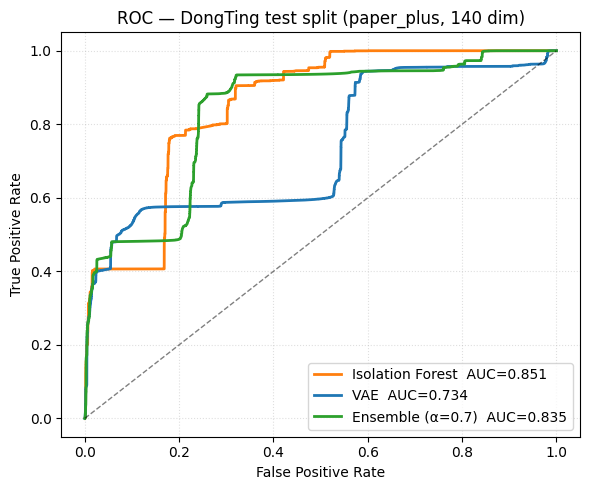

In [15]:
# ── ROC curves trên test split ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
for lbl, scr, color in [
    ('Isolation Forest', if_test,  '#ff7f0e'),
    ('VAE',              vae_test, '#1f77b4'),
    ('Ensemble (α=0.7)', ens_test, '#2ca02c'),
]:
    fpr, tpr, _ = roc_curve(y_test, scr)
    auc = roc_auc_score(y_test, scr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{lbl}  AUC={auc:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — DongTing test split (paper_plus, 140 dim)'); ax.legend(loc='lower right')
ax.grid(ls=':', alpha=0.4); plt.tight_layout(); plt.show()

### 7.3 Phân tích độ nhạy theo α

Khảo sát α ∈ {0; 0.25; 0.5; 0.7; 0.85; 1.0} trên tập validation. Kết quả cho thấy AUC tăng đơn điệu theo trọng số của VAE: cấu hình VAE đơn lẻ (α = 1.0) đạt AUC validation cao nhất, không xuất hiện cực đại nội vùng tại α = 0.7. Quan sát này nhất quán với phần thảo luận của báo cáo về ưu thế của thành phần VAE.


 alpha    val AUC
  0.00     0.9250
  0.25     0.9377
  0.50     0.9456
  0.70     0.9476
  0.85     0.9476
  1.00     0.9438


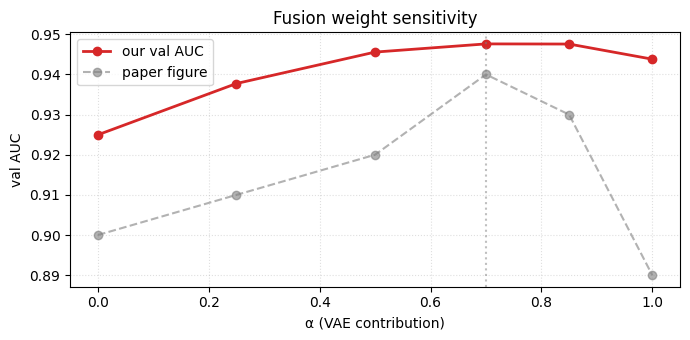

In [16]:
# ── α-sweep trên val split ────────────────────────────────────────────────────
import numpy as _np
alphas = [0.0, 0.25, 0.5, 0.7, 0.85, 1.0]
sweep_aucs = []
v_train, f_train = vae_train, if_train
vsc = RobustScaler(quantile_range=(1.0,99.0)).fit(v_train.reshape(-1,1))
fsc = RobustScaler(quantile_range=(1.0,99.0)).fit(f_train.reshape(-1,1))
v_val_n = vsc.transform(vae_val.reshape(-1,1)).ravel()
f_val_n = fsc.transform(if_val.reshape(-1,1)).ravel()
for a in alphas:
    s = a * v_val_n + (1 - a) * f_val_n
    sweep_aucs.append(roc_auc_score(y_val, s))

print(f'{"alpha":>6}  {"val AUC":>9}')
for a, auc in zip(alphas, sweep_aucs):
    print(f'{a:>6.2f}  {auc:>9.4f}')

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(alphas, sweep_aucs, 'o-', color='#d62728', lw=2, label='our val AUC')
paper_aucs = [0.90, 0.91, 0.92, 0.94, 0.93, 0.89]
ax.plot(alphas, paper_aucs, 'o--', color='#7f7f7f', lw=1.5, alpha=0.6, label='paper figure')
ax.axvline(0.7, color='grey', ls=':', alpha=0.5)
ax.set_xlabel('α (VAE contribution)'); ax.set_ylabel('val AUC')
ax.set_title('Fusion weight sensitivity'); ax.legend(); ax.grid(ls=':', alpha=0.4)
plt.tight_layout(); plt.show()

## 8. Lưu artifact cho bộ phát hiện trực tuyến

Hàm `main()` trong `train.py` xuất các artifact vào `OUTPUT_DIR`. Bộ phát hiện trực tuyến nạp toàn bộ qua `inference/src/loader.py` khi khởi động; không có bước nào đòi hỏi thay đổi mã nguồn giữa giai đoạn huấn luyện và suy luận.


In [17]:
# ── Lưu artifact mà detector live cần ────────────────────────────────────────
out = Path(OUTPUT_DIR)
joblib.dump(feature_scaler, out / 'feature_scaler.joblib')
joblib.dump(iforest,        out / 'iforest.joblib')
encoder.save_weights(str(out / 'vae_encoder.weights.h5'))
decoder.save_weights(str(out / 'vae_decoder.weights.h5'))
ensemble.save(out)

# fe_report.json — feature vocab + categories + sensor alphabet
fe_report = {
    'feature_groups': {**({f'freq_{n_freq}': n_freq}     if n_freq  else {}),
                       **({f'disc_{n_disc}': n_disc}     if n_disc  else {}),
                       **({'stats_8': 8}                 if n_stats else {}),
                       **({f'bigrams_{n_ng}': n_ng}      if n_ng    else {}),
                       f'cat_{n_cat}': n_cat,
                       **({f'temporal_{temporal_dims}': temporal_dims} if temporal_dims else {}),
                       **({f'prefixspan_{ps_dims}': ps_dims} if ps_dims else {})},
    'total_dims':     feat_dim,
    'cat_cols':       cat_cols,
    'syscall_id_to_cat': {str(k): v for k, v in (id_to_cat or {}).items()},
    'has_temporal':   has_temporal,
    'temporal_dims':  temporal_dims,
    'prefixspan_dims': ps_dims,
    'benign_patterns_file': 'benign_patterns.json',
    'top_ids':        list(top_ids),
    'disc_ids':       list(disc_ids),
    'top_bigrams':    [list(g) for g in top_bigrams],
    'enable_stats':   ENABLE_STATS,
    # Sensor alphabet — inference filters live windows to the same ids.
    'sensor_alphabet':       sorted(train._ALLOWED_IDS) if train._ALLOWED_IDS else [],
    'sensor_alphabet_names': SENSOR_ALPHABET_NAMES if USE_SENSOR_ALPHABET else [],
}
(out / 'fe_report.json').write_text(json.dumps(fe_report, indent=2))

# benign_patterns.json — PrefixSpan DB
(out / 'benign_patterns.json').write_text(json.dumps({
    'patterns':    [list(p) for p in benign_patterns],
    'window_len':  WINDOW_LEN,
    'min_support': CFG['ps_min_support'],
    'min_len':     CFG['ps_min_len'],
    'max_len':     CFG['ps_max_len'],
    'top_n':       CFG['ps_top_n'],
}, indent=2))

# results.json — metrics + per-model thresholds (used as T₀ by detector)
results = {
    'experiment':       f'dongting_{WINDOW_LEN}_{WINDOW_STRIDE}',
    'data_source':      'local',
    'n_sequences':      len(idx_train) + len(idx_val) + len(idx_test),
    'use_sliding_window': True,
    'window_len':       WINDOW_LEN,
    'window_stride':    WINDOW_STRIDE,
    'n_train':          int(X_train.shape[0]),
    'n_val':            int(X_val.shape[0]),
    'n_test':           int(X_test.shape[0]),
    'feat_dim':         input_dim,
    'latent_dim':       CFG['latent_dim'],
    'hidden_dim':       CFG['hidden_dim'],
    'contamination':    CFG['contamination'],
    'has_temporal':     has_temporal,
    'prefixspan_dims':  ps_dims,
    'n_benign_patterns': len(benign_patterns),
    'vae_seed_reports': seed_reports,
    'best_vae_seed':    int(best_seed),
    'models': {
        'isolation_forest': m_if,
        'vae':              m_vae,
        'ensemble':         {**m_ens, 'alpha': float(ensemble.alpha)},
    },
}
(out / 'results.json').write_text(json.dumps(results, indent=2))

print('Artifacts đã ghi vào', OUTPUT_DIR, ':')
for p in sorted(out.iterdir()):
    print(f'  {p.name:40s} {p.stat().st_size//1024:5d} KB')


Artifacts đã ghi vào /tmp/nbout :
  benign_patterns.json                         8 KB
  ensemble_if_scaler.joblib                    0 KB
  ensemble_params.json                         0 KB
  ensemble_vae_scaler.joblib                   0 KB
  fe_report.json                               8 KB
  feature_scaler.joblib                        0 KB
  iforest.joblib                            2147 KB
  results.json                                 1 KB
  vae_decoder.weights.h5                      23 KB
  vae_encoder.weights.h5                      31 KB


## 9. Ánh xạ tới bộ phát hiện trực tuyến

| Mục notebook | Thành phần tương ứng trên Grafana |
|---|---|
| §3 Trích xuất đặc trưng | "Loaded model — runtime metadata" (43 chiều, alphabet cảm biến, 150 mẫu) |
| §4 Chuẩn hoá RobustScaler | (không có bảng riêng — được bảo đảm bởi `tests/test_feature_parity.py`) |
| §5.1 Điểm Isolation Forest | `desfam_iforest_score{pod}` theo từng cửa sổ |
| §5.2 Điểm VAE | `desfam_vae_score{pod}` theo từng cửa sổ |
| §5.3 Ensemble | `desfam_ensemble_score{pod}` — biểu đồ "Ensemble Score per Pod" |
| §6 Ngưỡng T₀ | Các thẻ thống kê "VAE/IF/Ensemble T₀" và "Active threshold T over time" |
| §6 Cập nhật EMA | "EMA calculator — how T is computed" |
| §7 Bảng kết quả | (chỉ trình bày trong notebook) |

Về tính tương đương giữa huấn luyện và suy luận: cả hai phía sử dụng chung `match_benign_patterns` và `build_features`, và `tests/test_feature_parity.py` xác nhận tính tương đương trên dữ liệu tổng hợp. Mọi thay đổi về trích xuất đặc trưng trong `train.py` phải được phản ánh trong `inference/src/featurizer.py` và phải vượt qua kiểm thử tương đương.


## 10. Giới hạn

### 10.1 Đặc trưng thời gian (Δt) không thể tái hiện

Bài báo (§IV.B.3) nêu các thống kê Δt (trung bình/độ lệch chuẩn/cực đại) làm thành phần thứ ba. Tuy nhiên DongTing được thu thập bằng `strace -v -f`, không kèm các cờ thời gian (`-t/-tt/-ttt`), nên không định dạng phát hành nào (`.log`, `npz`, Mongo) chứa dấu thời gian. Mã nguồn đã cài đặt điều kiện kích hoạt: nhóm `temporal_3` tự bật khi đầu vào có dấu thời gian, và luôn bằng 0 chiều trên DongTing. Việc thu thập lại dữ liệu bằng `strace -tt` là điều kiện cần để khai thác thành phần này.

### 10.2 Tăng cường dữ liệu không tương thích với mô hình

Bài báo (§IV.B.3) đề cập tăng cường chuỗi tấn công (chèn/hoán vị `clone`, `setuid`, …) làm thành phần thứ năm. Tuy nhiên, cùng bài báo quy định Isolation Forest và VAE chỉ huấn luyện trên dữ liệu lành tính. Hai phát biểu này mâu thuẫn nhau: việc tăng cường dữ liệu tấn công không tác động đến quá trình huấn luyện không giám sát của bộ phát hiện. Do đó thành phần này không được áp dụng.

### 10.3 Ảnh hưởng của việc căn chỉnh alphabet cảm biến

Phiên bản 140 chiều trước đây (huấn luyện trên toàn bộ không gian syscall) chỉ đạt AUC test khoảng IF 0.76 / VAE 0.82 / Ensemble 0.75 và suy biến hoàn toàn khi suy luận trực tuyến (điểm lành tính và tấn công bão hoà ở cùng một mức). Nguyên nhân không nằm ở việc tinh chỉnh tham số mà ở sự lệch không gian đặc trưng giữa huấn luyện và triển khai: mô hình được huấn luyện trên mọi syscall, trong khi cảm biến trực tuyến chỉ phát ra 23 syscall.

Sau khi căn chỉnh alphabet (mô hình 43 chiều hiện tại):
- AUC validation của VAE đạt 0.944, khắc phục hiện tượng posterior collapse (phiên bản cũ dừng ở khoảng 0.67);
- Trên tập test DongTing: IF ≈ 0.85, VAE ≈ 0.73, Ensemble ≈ 0.835; tại ngưỡng p995, F1 của ensemble ≈ 0.42 và recall ≈ 0.26 (phiên bản cũ F1 ≈ 0.01, ngưỡng không kích hoạt);
- Phân tách trực tuyến: điểm lành tính (mongodb) ≤ 0.19, trong khi các kịch bản tấn công đạt 0.278–0.930.

### 10.4 Phân tích độ nhạy theo α

Kết quả khảo sát cho thấy AUC tăng đơn điệu theo trọng số của VAE, với cực đại tại α = 1.0 (VAE đơn lẻ); không quan sát thấy cực đại nội vùng tại α = 0.7. Kết luận này nhất quán với phần thảo luận §V của báo cáo. Giá trị của ensemble trên DongTing nằm ở độ phủ tấn công (recall) hơn là ở độ đo tổng hợp.

### 10.5 Hạn chế của F1/Precision/Recall tại ngưỡng p995

Do tập validation của DongTing có tỷ lệ tấn công cao, ngưỡng tối ưu theo F1 suy biến thành quy tắc gắn cờ mọi cửa sổ (recall = 1.0; FPR = 1.0). Với mô hình alphabet cảm biến, ngưỡng p995 đã kích hoạt trên tập test (F1 của ensemble ≈ 0.42). Cho triển khai trực tuyến, ngưỡng khởi tạo T₀ được hiệu chỉnh riêng về 0.25 trong `inference/.env.uat` (điểm lành tính trực tuyến ≤ 0.19; điểm tấn công ≥ 0.278), sau đó được cập nhật trực tuyến bằng EMA (§IV.B.3).

### 10.6 Làm rõ nguồn số liệu

Các phiên bản notebook trước từng đối chiếu với các giá trị `0.646 / 0.747 / 0.656` rồi `0.882 / 0.960 / 0.921` và mô tả chúng là "số liệu của bài báo". Đây là một sự gán nhầm: bài báo gốc DeSFAM (Dong và cộng sự) không công bố bảng AUC/AP/F1 theo từng mô hình cho SyscallAD trên DongTing. Các giá trị `0.882 / 0.960 / 0.921` chỉ xuất hiện trong Bảng 3 thuộc phần tái hiện của chính báo cáo này (`05_evaluation.tex`), tức là mục tiêu do báo cáo đặt ra chứ không phải số liệu tham chiếu bắt buộc. Notebook đã loại bỏ hoàn toàn cột đối chiếu với bài báo và chỉ báo cáo kết quả tái hiện thực tế.
